# 01. Data Loading and Exploration

**Project:** KPI-RAG: Explainable Root-Cause Analysis for 5G Networks
**Dataset:** TelecomTS (Feng et al., ICML 2026)

This notebook covers two stages:
- **Loading:** Read the raw CSV, validate the structure, and save to Parquet for fast reloading.
- **Exploration:** Understand anomaly distribution, inspect KPI channels, and examine tickets and QnA entries that will form the RAG corpus.

**Output:** `data/telecomts_full.parquet` used by all subsequent notebooks.

---

| Column | Description | Used in classifier? |
|---|---|---|
| `start_time`, `end_time` | Window timestamps | No |
| `sampling_rate` | Measurement resolution in ms | No |
| `KPIs` | 16 numerical channels, 128 timesteps each | Yes - feature source |
| `description` | Natural language KPI summary | No - RAG only |
| `anomalies` | Anomaly flag, type, root cause, ticket | No - RAG only |
| `statistics` | Pre-computed channel statistics | No - label-derived, excluded |
| `labels` | Zone, application, mobility, anomaly_present | No - label-derived, excluded |
| `QnA` | Structured Q&A with reasoning traces | No - RAG only |

## 1. Imports and Configuration

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import os
import re
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

print(f'pandas:  {pd.__version__}')
print(f'numpy:   {np.__version__}')

pandas:  3.0.3
numpy:   2.4.6


In [46]:
COLORS = {
    'normal':     '#2E6DB4',  # Steel Blue   — normal class
    'anomaly':    '#C0392B',  # Crimson      — anomaly class
    'jamming':    '#E67E22',  # Dark Orange  — Jamming (real anomaly)
    'synthetic':  '#85929E',  # Light Slate  — synthetic anomaly types
    'axis':       '#2C3E50',  # Dark Navy    — axis labels and titles
    'grid':       '#F2F4F6',  # Off White    — gridlines
    'background': '#FFFFFF',  # White        — figure background
}

## 2. Data Loading

### 2.1 Load from CSV

The CSV contains nested Python objects stored as strings inside each field.
`quoting=1` is required to prevent pandas from splitting on commas inside nested array fields.
`on_bad_lines='skip'` drops the small number of malformed rows silently.

In [6]:
DATA_CSV     = r'C:\Users\DELL\Desktop\kpi_rag\data\telecomts.csv'
DATA_PARQUET = r'C:\Users\DELL\Desktop\kpi_rag\data\telecomts_full.parquet'

file_size_gb = os.path.getsize(DATA_CSV) / 1e9
print(f'File size: {file_size_gb:.2f} GB')
print('Loading...')

df = pd.read_csv(
    DATA_CSV,
    sep=',',
    quoting=1,
    on_bad_lines='skip',
    engine='python',
    encoding='utf-8'
)

print(f'Rows:    {len(df):,}')
print(f'Columns: {df.columns.tolist()}')

File size: 1.22 GB
Loading...
Rows:    32,000
Columns: ['start_time', 'end_time', 'sampling_rate', 'KPIs', 'description', 'anomalies', 'statistics', 'labels', 'QnA']


### 2.2 Parse Anomaly Fields

Extracts `anomaly_type` and `anomaly_status` from the nested `anomalies` column.
These two derived columns are used for stratification and evaluation only - not as classifier inputs.

In [7]:
def get_anomaly_type(text):
    match = re.search(r"'type':\s*'([^']+)'", str(text))
    return match.group(1) if match else 'Normal'

def get_anomaly_status(text):
    return 'Anomaly' if "'exists': True" in str(text) else 'Normal'

df['anomaly_type']   = df['anomalies'].apply(get_anomaly_type)
df['anomaly_status'] = df['anomalies'].apply(get_anomaly_status)

print(f'Columns after parsing: {df.columns.tolist()}')

Columns after parsing: ['start_time', 'end_time', 'sampling_rate', 'KPIs', 'description', 'anomalies', 'statistics', 'labels', 'QnA', 'anomaly_type', 'anomaly_status']


### 2.3 Parse Timestamps

In [8]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time']   = pd.to_datetime(df['end_time'])

print(f'Start:         {df["start_time"].min()}')
print(f'End:           {df["start_time"].max()}')
print(f'Sampling rate: {df["sampling_rate"].mode()[0]} ms')
print()
print('Note: The date range extends to 2037 because TelecomTS concatenates')
print('multiple recording sessions with sequentially assigned timestamps.')
print('Timestamps are not used as features in the classifier.')

Start:         2025-01-01 00:00:00
End:           2037-04-08 00:11:40.800000
Sampling rate: 10 ms

Note: The date range extends to 2037 because TelecomTS concatenates
multiple recording sessions with sequentially assigned timestamps.
Timestamps are not used as features in the classifier.


### 2.4 Check for Missing Values

In [19]:
# 2.4 Validate Structure

# Shape check
expected_rows = 32000
expected_cols = 9
row_diff = expected_rows - len(df)

print('Shape Validation:')
print(f'  Expected rows: {expected_rows:,}')
print(f'  Actual rows:   {len(df):,}')
print(f'  Dropped rows:  {row_diff}')

if row_diff > 50:
    print('  WARNING: More than 50 rows dropped.')
else:
    print('  Row count acceptable.')

if len(df.columns) < expected_cols:
    print(f'  WARNING: Expected {expected_cols} columns, got {len(df.columns)}.')
else:
    print(f'  Columns: {len(df.columns)} ')

# Missing values
print()
missing = df.isnull().sum()
has_missing = missing[missing > 0]

if len(has_missing) == 0:
    print('Missing values: None found.')
else:
    print('Missing values:')
    print(has_missing.to_string())

# Ticket check
anomalous_df = df[df['anomaly_status'] == 'Anomaly']
has_ticket = anomalous_df['anomalies'].apply(
    lambda x: 'troubleshooting_tickets' in str(x)
).sum()

print(f'\nAnomaly rate:         {(df["anomaly_status"] == "Anomaly").mean() * 100:.1f}%')
print(f'Samples with tickets: {has_ticket:,} / {len(anomalous_df):,}')

Shape Validation:
  Expected rows: 32,000
  Actual rows:   32,000
  Dropped rows:  0
  Row count acceptable.
  Columns: 11 

Missing values: None found.

Anomaly rate:         3.9%
Samples with tickets: 1,235 / 1,235


### 2.5 Save to Parquet

Parquet loads approximately 10x faster than the raw CSV.
All subsequent notebooks load from this file instead of the raw CSV.

In [10]:
df.to_parquet(DATA_PARQUET, index=False)

saved_size_mb = os.path.getsize(DATA_PARQUET) / 1e6
print(f'Saved: {DATA_PARQUET}')
print(f'Size:  {saved_size_mb:.1f} MB')
print(f'Rows:  {len(df):,}')

Saved: C:\Users\DELL\Desktop\kpi_rag\data\telecomts_full.parquet
Size:  367.8 MB
Rows:  32,000


## 3. Data Exploration

### 3.1 Anomaly Type Distribution

In [48]:
# 3.1 Anomaly Distribution — Statistics

total         = len(df)
normal_count  = (df['anomaly_status'] == 'Normal').sum()
anomaly_count = (df['anomaly_status'] == 'Anomaly').sum()

print('Class Distribution:')
print(f'  Total samples: {total:,}')
print(f'  Normal:        {normal_count:,}  ({normal_count/total*100:.1f}%)')
print(f'  Anomaly:       {anomaly_count:,}  ({anomaly_count/total*100:.1f}%)')

print()
print('Anomaly Type Breakdown:')
print(f'  {"Type":<45} {"Count":>6}  {"% of Anomalies":>15}')
print(f'  {"-"*45} {"-"*6}  {"-"*15}')

type_counts = df[df['anomaly_status'] == 'Anomaly']['anomaly_type'].value_counts()
for anomaly_type, count in type_counts.items():
    pct = count / anomaly_count * 100
    print(f'  {anomaly_type:<45} {count:>6}  {pct:>14.1f}%')

Class Distribution:
  Total samples: 32,000
  Normal:        30,765  (96.1%)
  Anomaly:       1,235  (3.9%)

Anomaly Type Breakdown:
  Type                                           Count   % of Anomalies
  --------------------------------------------- ------  ---------------
  Jamming                                          279            22.6%
  Co-Channel Interference (Mild)                   146            11.8%
  Buffer Overflow (Gradual Buildup)                138            11.2%
  Co-Channel Interference (Severe)                 114             9.2%
  Antenna Failure                                  107             8.7%
  Faulty RF Filters (Temporal)                     100             8.1%
  High Network Congestion (Gradual Buildup)         93             7.5%
  Doppler Shift (Severe)                            86             7.0%
  Faulty Handover Algorithm (Too Frequent)          64             5.2%
  Resource Allocation Bugs                          60             4.9%
  H

### 3.2 Anomaly Distribution — Pie Chart

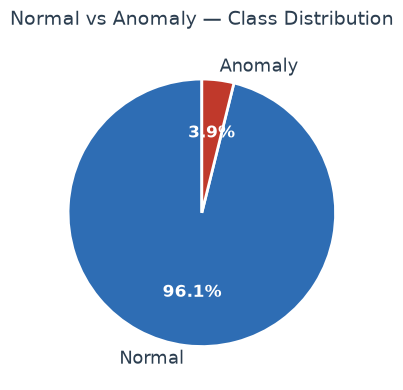


Observation:
  The dataset is heavily imbalanced — 96.1% normal vs 3.9% anomalous.
  This reflects real-world network conditions where faults are rare.
  This imbalance drives two design decisions:
    1. Rebalancing training data to 80/20 for Model 1(Binary Anomaly Detector).
    2. Using F1 score on the anomalous class as the primary metric,
       not overall accuracy which would be misleading.


In [50]:
# 3.2 Anomaly Distribution — Pie Chart

fig, ax = plt.subplots(figsize=(4, 4))

labels = ['Normal', 'Anomaly']
sizes  = [normal_count, anomaly_count]
colors = [COLORS['normal'], COLORS['anomaly']]

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for text in texts:
    text.set_fontsize(13)
    text.set_color(COLORS['axis'])

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Normal vs Anomaly — Class Distribution', fontsize=14,
             color=COLORS['axis'], pad=15)

plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\kpi_rag\data\pie_distribution.png', dpi=150)
plt.show()

print()
print('Observation:')
print('  The dataset is heavily imbalanced — 96.1% normal vs 3.9% anomalous.')
print('  This reflects real-world network conditions where faults are rare.')
print('  This imbalance drives two design decisions:')
print('    1. Rebalancing training data to 80/20 for Model 1(Binary Anomaly Detector).')
print('    2. Using F1 score on the anomalous class as the primary metric,')
print('       not overall accuracy which would be misleading.')

### 3.3 Anomaly Distribution — Bar Chart

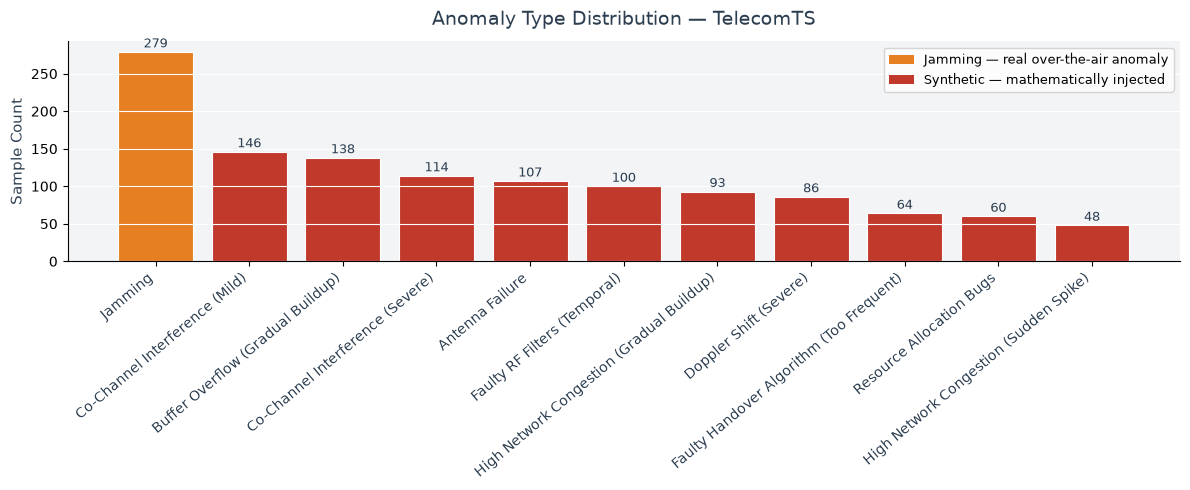


Observations:
  - Jamming is the only real anomaly — physically induced in the testbed.
    It is highlighted in orange and excluded from Model 2 (11-Class Fault Classifier) training.
    It is used as a zero-exposure generalization probe.
  - All other 10 types are synthetically injected.
  - Class sizes vary significantly — Congestion Sudden (48 samples)
    and Resource Allocation Bugs (60 samples) are the smallest classes.
    F1 scores for these types will have higher variance.


In [52]:
# 3.3 Anomaly Distribution — Bar Chart by Type

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = [COLORS['anomaly'] if t != 'Jamming' else COLORS['jamming']
              for t in type_counts.index]

bars = ax.bar(
    range(len(type_counts)),
    type_counts.values,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

ax.set_xticks(range(len(type_counts)))
ax.set_xticklabels(type_counts.index, rotation=40, ha='right',
                   fontsize=10, color=COLORS['axis'])
ax.set_ylabel('Sample Count', fontsize=11, color=COLORS['axis'])
ax.set_title('Anomaly Type Distribution — TelecomTS', fontsize=14,
             color=COLORS['axis'], pad=12)
ax.set_facecolor(COLORS['grid'])
ax.grid(axis='y', color='white', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)

for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(count), ha='center', va='bottom',
            fontsize=9, color=COLORS['axis'])

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['jamming'], label='Jamming — real over-the-air anomaly'),
    Patch(facecolor=COLORS['anomaly'], label='Synthetic — mathematically injected'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(r'C:\Users\DELL\Desktop\kpi_rag\data\bar_anomaly_types.png', dpi=150)
plt.show()

print()
print('Observations:')
print('  - Jamming is the only real anomaly — physically induced in the testbed.')
print('    It is highlighted in orange and excluded from Model 2 (11-Class Fault Classifier) training.')
print('    It is used as a zero-exposure generalization probe.')
print('  - All other 10 types are synthetically injected.')
print('  - Class sizes vary significantly — Congestion Sudden (48 samples)')
print('    and Resource Allocation Bugs (60 samples) are the smallest classes.')
print('    F1 scores for these types will have higher variance.')

### 3.4 KPI Channel Names

Extracts and confirms the 16 numerical KPI channels available in the dataset.
These are the channels used to build the 582-dimensional feature vector in Notebook 02.

In [12]:
def get_kpi_channel_names(kpi_text):
    return re.findall(r"'(\w+)':\s*array", str(kpi_text))

kpi_channels = get_kpi_channel_names(df['KPIs'].iloc[0])

print(f'KPI channels found: {len(kpi_channels)}')
for i, ch in enumerate(kpi_channels, 1):
    print(f'  {i:2}. {ch}')

KPI channels found: 18
   1. RSRP
   2. DL_BLER
   3. DL_MCS
   4. UL_BLER
   5. UL_MCS
   6. UL_NPRB
   7. UL_SNR
   8. TX_Bytes
   9. RX_Bytes
  10. Estimated_UL_Buffer
  11. PRBs_DL_Current
  12. PRBs_UL_Current
  13. PRB_Utilization_DL
  14. PRB_Utilization_UL
  15. UL_Protocol
  16. UL_NumberOfPackets
  17. DL_Protocol
  18. DL_NumberOfPackets


### 3.5 KPI Statistics per Channel

Extracts the mean value of each KPI channel from the pre-computed `statistics` field.
This section is for exploration only - the `statistics` column is excluded from classifier inputs
to prevent label leakage.

In [13]:
def extract_kpi_mean(stats_text, kpi_name):
    match = re.search(rf"'{kpi_name}'.*?'mean':\s*([-\d.]+)", str(stats_text))
    return float(match.group(1)) if match else None

sample_500 = df.sample(500, random_state=42)

print(f'{"Channel":<30} {"Mean":>10}')
print('-' * 42)

for ch in kpi_channels:
    values = sample_500['statistics'].apply(lambda x: extract_kpi_mean(x, ch)).dropna()
    if len(values) > 0:
        print(f'{ch:<30} {values.mean():>10.3f}')

Channel                              Mean
------------------------------------------
RSRP                             -106.011
DL_BLER                             0.630
DL_MCS                              6.827
UL_BLER                             0.202
UL_MCS                             14.144
UL_NPRB                            12.545
UL_SNR                             20.438
TX_Bytes                       168801.431
RX_Bytes                         3141.046
Estimated_UL_Buffer               444.242
PRBs_DL_Current                    26.221
PRBs_UL_Current                     0.873
PRB_Utilization_DL                 24.747
PRB_Utilization_UL                  0.831
UL_NumberOfPackets                 26.585
DL_NumberOfPackets                 99.195


### 3.6 Normal vs Anomaly KPI Comparison

Compares mean KPI values between normal and anomalous samples.
This confirms that KPI signals differ between classes, validating the ML classification approach.

In [14]:
normal_sample  = df[df['anomaly_status'] == 'Normal'].sample(200, random_state=42)
anomaly_sample = df[df['anomaly_status'] == 'Anomaly'].sample(200, random_state=42)

for ch in ['RSRP', 'DL_BLER', 'UL_SNR']:
    normal_means  = normal_sample['statistics'].apply(lambda x: extract_kpi_mean(x, ch)).dropna()
    anomaly_means = anomaly_sample['statistics'].apply(lambda x: extract_kpi_mean(x, ch)).dropna()

    print(f'{ch}:')
    print(f'  Normal  mean: {normal_means.mean():.3f}')
    print(f'  Anomaly mean: {anomaly_means.mean():.3f}')
    print()

RSRP:
  Normal  mean: -104.085
  Anomaly mean: -100.916

DL_BLER:
  Normal  mean: 0.400
  Anomaly mean: 0.213

UL_SNR:
  Normal  mean: 20.593
  Anomaly mean: 18.604



### 3.7 Inspect One Normal Sample

In [21]:
# 3.5 Inspect One Normal Sample

normal_display = df[df['anomaly_status'] == 'Normal'].iloc[0]

print('Normal Sample:')
print(f'  start_time:    {normal_display["start_time"]}')
print(f'  sampling_rate: {normal_display["sampling_rate"]} ms')
print(f'  anomaly_status: {normal_display["anomaly_status"]}')
print()
print('KPIs (first 300 characters):')
print(str(normal_display['KPIs'])[:300])
print()
print('description:')
print(str(normal_display['description'])[:300])
print()
print('anomalies field:')
print(str(normal_display['anomalies'])[:200])

Normal Sample:
  start_time:    2037-03-11 00:12:25.600000
  sampling_rate: 10 ms
  anomaly_status: Normal

KPIs (first 300 characters):
{'RSRP': array([-113.24      , -113.        , -113.        , -113.        ,
       -113.        , -113.        , -113.        , -112.33      ,
       -112.        , -112.        , -112.        , -112.        ,
       -112.        , -112.        , -112.64516129, -113.        ,
       -113.        , -

description:
RSRP steadily improved early in the capture, rising over indices 1–53 (≈5.2 s) at about +1.155 dB/s; RSRP values ranged between -116.7 dB and -106.0 dB. The average RSRP across the trace was -111.6 dB. UL MCS showed large swings: it fell to 0 and later recovered to as high as 16, with overall UL_MCS

anomalies field:
{'exists': False, 'type': '', 'anomaly_duration': {'start': None, 'end': None}, 'affected_kpis': array([''], dtype=object), 'troubleshooting_tickets': ''}


### 3.8 — Inspect One Anomalous Sample

In [22]:
# 3.6 Inspect One Anomalous Sample

anomalous_display = df[df['anomaly_status'] == 'Anomaly'].iloc[0]

print('Anomalous Sample:')
print(f'  start_time:    {anomalous_display["start_time"]}')
print(f'  anomaly_type:  {anomalous_display["anomaly_type"]}')
print(f'  sampling_rate: {anomalous_display["sampling_rate"]} ms')
print()
print('KPIs (first 300 characters):')
print(str(anomalous_display['KPIs'])[:300])
print()
print('anomalies (first 500 characters):')
print(str(anomalous_display['anomalies'])[:500])
print()
print('QnA (first 300 characters):')
print(str(anomalous_display['QnA'])[:300])

Anomalous Sample:
  start_time:    2025-01-01 00:05:33
  anomaly_type:  Jamming
  sampling_rate: 10 ms

KPIs (first 300 characters):
{'RSRP': array([-73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  ,
       -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  ,
       -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  ,
       -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  , -73.  ,
       

anomalies (first 500 characters):
{'exists': True, 'type': 'Jamming', 'anomaly_duration': {'start': 0, 'end': 127}, 'affected_kpis': array(['DL_BLER', 'UL_BLER', 'UL_MCS', 'TX_Bytes', 'RX_Bytes'],
      dtype=object), 'troubleshooting_tickets': '**Diagnose Summary:** **Issue:** Severe communication degradation in the wireless network due to external interference. **Symptoms:** DL_BLER and UL_BLER increase, UL_MCS decreases, and TX_Bytes and RX_Bytes experience drops. **Root Cause:** Active jammer generating continuous radio inte

QnA (first 300 characters):
{

### 3.9 Ticket display

In [23]:
# 3.7 Sample Troubleshooting Ticket

sample_anomaly = df[df['anomaly_status'] == 'Anomaly'].iloc[0]
anomaly_str    = str(sample_anomaly['anomalies'])

print(f'Anomaly type: {sample_anomaly["anomaly_type"]}')
print()

for field in ['issue', 'symptoms', 'root_cause', 'resolution']:
    match = re.search(rf"'{field}':\s*'([^']+)'", anomaly_str, re.IGNORECASE)
    if match:
        print(f'{field.upper()}:')
        print(f'  {match.group(1)}')
        print()

Anomaly type: Jamming



### 3.10 Sample QnA Entry

In [25]:
# 3.8 Sample QnA Entry

sample_anomaly = df[df['anomaly_status'] == 'Anomaly'].iloc[0]

print('Sample QnA entry (first 600 characters):')
print(str(sample_anomaly['QnA'])[:600])

Sample QnA entry (first 600 characters):
{'network': array([{'q': 'From YouTube, Twitch, or File download, which was active?', 'a': 'File download was active.', 'reasoning': "Beginning from the start of the window, 5G signal strength is measured as RSRP -75 dB to -73 dB, which is consistently strong. The RSRP indicates good signal quality, which is typical for high-throughput scenarios. The UL_MCS shows some variability, ranging from 9 to 18 with drops to 9 and 11, suggesting occasional uplink quality degradation. Meanwhile, DL_MCS is consistently low at 7.0, indicating a stable downlink channel but not high throughput. Uplink BLER i


### 3.11 KPI Array Length Validation
 Confirms every sample has exactly 128 timesteps per channel. If any sample is shorter, the feature vector will be wrong.

In [59]:
# Verify KPI array length — expected 128 timesteps per channel

import ast
import re

def get_kpi_length(kpi_text):
    match = re.search(r"'RSRP':\s*array\(\[(.*?)\]", str(kpi_text), re.DOTALL)
    if not match:
        return None
    values = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', match.group(1))
    return len(values)

sample_lengths = df['KPIs'].apply(get_kpi_length)

print(f'Min timesteps: {sample_lengths.min()}')
print(f'Max timesteps: {sample_lengths.max()}')
print(f'All samples have 128 timesteps: {(sample_lengths == 128).all()}')

if not (sample_lengths == 128).all():
    n_short = (sample_lengths != 128).sum()
    print(f'WARNING: {n_short} samples do not have 128 timesteps.')

Min timesteps: 128
Max timesteps: 128
All samples have 128 timesteps: True


## 4. Validation Summary

Final confirmation that all required conditions are met before proceeding to Notebook 02.

In [60]:
checks = {
    'Row count acceptable (>= 31,950)':     len(df) >= 31950,
    'Column count correct (11)':            len(df.columns) == 11,
    'Sampling rate is 10 ms':               df['sampling_rate'].mode()[0] == 10,
    'Anomaly types >= 11':                  df['anomaly_type'].nunique() >= 11,
    'Anomaly rate between 3% and 5%':       0.03 <= (df['anomaly_status'] == 'Anomaly').mean() <= 0.05,
    'All anomalous samples have tickets':   has_ticket == len(anomalous_df),
    'KPI channels confirmed (18)':          len(kpi_channels) == 18,
    'Parquet file saved':                   os.path.exists(DATA_PARQUET),
}

all_passed = True
for check, passed in checks.items():
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}] {check}')
    if not passed:
        all_passed = False

print()
if all_passed:
    print('All checks passed')
else:
    print('One or more checks failed. Investigate before proceeding.')

[PASS] Row count acceptable (>= 31,950)
[PASS] Column count correct (11)
[PASS] Sampling rate is 10 ms
[PASS] Anomaly types >= 11
[PASS] Anomaly rate between 3% and 5%
[PASS] All anomalous samples have tickets
[PASS] KPI channels confirmed (18)
[PASS] Parquet file saved

All checks passed


In [55]:
print(f'KPI channels found: {len(kpi_channels)}')
print(f'Channel names: {kpi_channels}')

KPI channels found: 18
Channel names: ['RSRP', 'DL_BLER', 'DL_MCS', 'UL_BLER', 'UL_MCS', 'UL_NPRB', 'UL_SNR', 'TX_Bytes', 'RX_Bytes', 'Estimated_UL_Buffer', 'PRBs_DL_Current', 'PRBs_UL_Current', 'PRB_Utilization_DL', 'PRB_Utilization_UL', 'UL_Protocol', 'UL_NumberOfPackets', 'DL_Protocol', 'DL_NumberOfPackets']
